In [1]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from utils import plot_confusion_matrix, compute_permuted_accuracy
from sklearn.cluster import KMeans
from ucimlrepo import fetch_ucirepo
from convex_nmf import ConvexNMF

In [2]:
# fetch dataset 
ionosphere = fetch_ucirepo(id=52) 
  
# data (as pandas dataframes) 
X = ionosphere.data.features # num_samples x num_features with 2 classes (clusters)
y = ionosphere.data.targets
y = [0 if label == 'g' else 1 for label in y['Class']]

In [3]:
kmeans_clustering_accuracies = []
random_state = 22
num_iter = 10
for i in range(num_iter):
    kmeans = KMeans(n_clusters=2, tol = 1e-6, random_state = random_state * i)
    kmeans_labels = kmeans.fit_predict(X)
    cm = plot_confusion_matrix(y_true = y, y_pred = kmeans_labels, plot =False, normalize = False)
    accuracy = compute_permuted_accuracy(cm)
    print(f"Total iterations for kmeans: {kmeans.n_iter_}. Accuracy on iteration {i}: {accuracy}")
    kmeans_clustering_accuracies.append(accuracy)

print(f'Average accuracy: {np.mean(kmeans_clustering_accuracies)}')

Total iterations for kmeans: 4. Accuracy on iteration 0: 0.7122507122507122
Total iterations for kmeans: 6. Accuracy on iteration 1: 0.7094017094017094
Total iterations for kmeans: 5. Accuracy on iteration 2: 0.7122507122507122
Total iterations for kmeans: 6. Accuracy on iteration 3: 0.7122507122507122
Total iterations for kmeans: 6. Accuracy on iteration 4: 0.7122507122507122
Total iterations for kmeans: 8. Accuracy on iteration 5: 0.7094017094017094
Total iterations for kmeans: 9. Accuracy on iteration 6: 0.7122507122507122
Total iterations for kmeans: 14. Accuracy on iteration 7: 0.7122507122507122
Total iterations for kmeans: 5. Accuracy on iteration 8: 0.7122507122507122
Total iterations for kmeans: 13. Accuracy on iteration 9: 0.7122507122507122
Average accuracy: 0.7116809116809117


The Ding-Li-Jordan paper has the K-means accuracy at ```0.4217```. Not sure how they got this, but they also didn't specify if all features were used in clustering.

In [4]:
convex_nmf_clustering_accuracies = []
CNMF = ConvexNMF(X = np.array(X.T), r=2, tol=1e-6, max_iter=5000, random_state=random_state * i)
for i in range(num_iter):
    F, W, G_T, residual_vector = CNMF.factorize()
    G = G_T.T
    convex_nmf_clusters = [1 if G[i, 0] > G[i, 1] else 0 for i in range(351)]
    cm = plot_confusion_matrix(y_true = y, y_pred = convex_nmf_clusters, plot = False, normalize = False)
    accuracy = compute_permuted_accuracy(cm)
    print(f'Accuracy on iteration {i}: {accuracy}')
    convex_nmf_clustering_accuracies.append(accuracy)

print(f'Average accuracy: {np.mean(convex_nmf_clustering_accuracies)}')

 20%|██        | 1016/5000 [00:05<00:21, 187.26it/s]


Convergence achieved at iteration 1016...
Accuracy on iteration 0: 0.5982905982905983


 20%|██        | 1016/5000 [00:05<00:20, 192.54it/s]


Convergence achieved at iteration 1016...
Accuracy on iteration 1: 0.5982905982905983


 20%|██        | 1016/5000 [00:05<00:21, 183.94it/s]


...

Convergence achieved at iteration 1016...
Accuracy on iteration 7: 0.5982905982905983


 20%|██        | 1016/5000 [00:05<00:20, 195.12it/s]


Convergence achieved at iteration 1016...
Accuracy on iteration 8: 0.5982905982905983


 20%|██        | 1016/5000 [00:05<00:20, 192.29it/s]

Convergence achieved at iteration 1016...
Accuracy on iteration 9: 0.5982905982905983
Average accuracy: 0.5982905982905982


Again the Ding-Li-Jordan paperh as their Convex-NMF clustering accuracy at around ```0.5470```, so our simulations are atleast slightly closer this time around

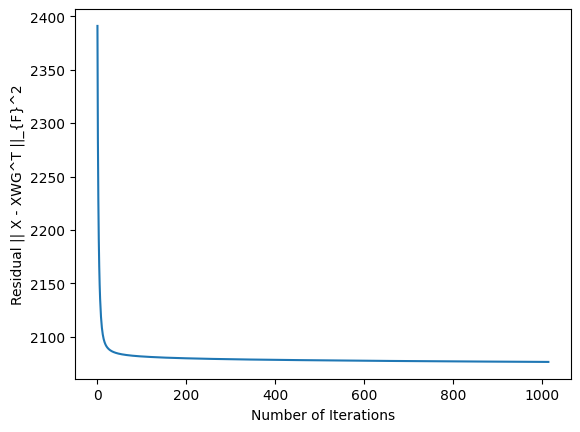

In [5]:
plt.plot(residual_vector)
plt.xlabel('Number of Iterations')
plt.ylabel('Residual || X - XWG^T ||_{F}^2')
plt.show()